# Imports and definitions

In [1]:
# imports
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from matplotlib.patches import Patch
from kuibit.simdir import SimDir
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numpy import sqrt
from numpy import pi
import pandas as pd
import numpy as np
import os

In [2]:
# display dynamical plots
%matplotlib widget

In [ ]:
# change the directory to cactus here
CACTUS_ROOT = "/home/undercover/projects/cactus"

In [ ]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl {CACTUS_ROOT}/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

In [4]:
def get_tau_fission(simulation, start, stop):
    sd      = SimDir(simulation)
    ts      = sd.timeseries
    gc_norm = ts.norm2["gc"]

    hor  = sd.horizons
    hor1 = hor.get_apparent_horizon(1)

    # the weirdest way possible to get all of the timesteps, but it works
    time_steps = [
        int(gc_norm.t[i]) if gc_norm.t[i] == int(gc_norm.t[i]) else gc_norm.t[i] for i in range(0, len(gc_norm))
    ]

    c_x = hor1.get_ah_property("centroid_x")
    c_y = hor1.get_ah_property("centroid_y")
    c_z = hor1.get_ah_property("centroid_z")

    t = c_x.t
    r = sqrt((c_x.values-c_x.values[0])**2 + (c_y.values-c_y.values[0])**2 + (c_z.values-c_z.values[0])**2)

    f = interp1d(t, r, kind='cubic')

    tau_i = root_scalar(lambda x: f(x) - start, bracket=[t[0],t[-1]], method='brentq')
    tau_f = root_scalar(lambda x: f(x) - stop,  bracket=[t[0],t[-1]], method='brentq')

    if (not tau_i["converged"]) or (not tau_f["converged"]):
        raise Exception(f"{simulation} didn't converge")

    tau_i = tau_i["root"]
    tau_f = tau_f["root"]
    delta_tau = tau_f - tau_i

    return (tau_i, delta_tau)

In [5]:
def get_tau_absorption(simulation, start, stop):
    sd = SimDir(simulation)
    ts = sd.timeseries

    # we need alpha to perform conversions between conventions
    sim_split = simulation.replace("-","_").split("_")
    for i in sim_split:
        if "alpha" in i:
            alpha = float(i.split("=")[1])

    # here's the charge of the scalar field
    Q_phi = ts.scalar["Q_phi"]

    # interpolate Q_phi, and perform change of convetions here
    f = interp1d(Q_phi.t, sqrt(4*pi)/alpha*(2*Q_phi.y), kind='cubic')

    # compute tau_i and delta_tau
    tau_i = root_scalar(lambda x: f(x) - start, bracket=[Q_phi.t[0],Q_phi.t[-1]], method='brentq')
    tau_f = root_scalar(lambda x: f(x) - stop,  bracket=[Q_phi.t[0],Q_phi.t[-1]], method='brentq')

    if (not tau_i["converged"]) or (not tau_f["converged"]):
        raise Exception(f"{simulation} didn't converge")

    tau_i = tau_i["root"]
    tau_f = tau_f["root"]
    delta_tau = tau_f - tau_i

    return (tau_i, delta_tau)

# $r_h = 0.2$

In [10]:
# csv file
csv = "data/rh=0.2_lower.csv"

# simulations folder
simulations = lambda omega: f"../../simulations/cloud-stat_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w={omega}_h=4"

# simulations go here
# in this case all of them have the fission scenario
omegas = [
    "0.700",
    "0.750",
    "0.800",
    "0.850",
    "0.900"
]

# radius in which there is X%, (1-X)% of the total initial charge distribution of the scalar field
# computed using the Mathematica notebook "7. Get numerical value of charge and mass.nb"
start_stop = {
    # 1%, 99%
    "1": [
        (0.607092, 5.63719),
        (0.420971, 4.85862),
        (0.33962,  4.56466),
        (0.285816, 4.46442),
        (0.238863, 4.52969)
    ],

    # 5%, 95%
    "5": [
        (1.21118,  4.7089),
        (0.844518, 3.88459),
        (0.678487, 3.53109),
        (0.574216, 3.34654),
        (0.501876, 3.28259)
    ],

    # 10%, 90%
    "10": [
        (1.60657,  4.29566),
        (1.13709,  3.46179),
        (0.919958, 3.09061),
        (0.781412, 2.87871),
        (0.684408, 2.77166)
    ]
}

# import the CSV
# the colums will be indexed by the column names
# the rows will be indexed by the values of omega
# due to the way this is coded, the values of omega will disappear from the dataframe, but we can fetch them via `df.index.to_list()`
df = pd.read_csv(csv, comment="#", index_col=0)
df.index.name = None

# go over all percentages and write to the corresponding column in the file
for percentage in start_stop.keys():
    for i in range(0, len(omegas)):
        omega       = omegas[i]
        simulation  = simulations(omega)
        start, stop = start_stop[percentage][i]

        # some of them might not have finished running yet
        try:
            tau_i, delta_tau = get_tau_fission(simulation, start, stop)
            print(f"{tau_i}, {delta_tau}")

        except Exception as ex:
            print(f"error on computing tau: {ex}")
            continue

        # modify the relevant entries on the dataframe
        df.loc[float(omega),f"tau_i_{percentage}"]     = tau_i
        df.loc[float(omega),f"delta_tau_{percentage}"] = delta_tau

    # here's a print to seperate different percentages
    print()

# update the CSV
df = df.reset_index()                                # reset the index to include "omega" as a column
df.rename(columns={'index': 'omega'}, inplace=True)  # rename the index column to "omega"
os.system(f"sed -i '/^[^#]/d' {csv}")                # remove all lines that aren't comments from the CSV
df.to_csv(csv, mode='a', index=False)                # append current dataframe to the CSV

1098.496673365452, 224.44255892121487
658.4779295899355, 246.1911651079905
510.8018929991234, 268.50853680799514
420.25995972251184, 298.69902992100873
351.9127528722276, 440.2887454156083

1134.1582153565626, 151.29631569705293
687.8048396637871, 166.52388529507004
537.1359328803628, 180.20680507326847
445.09185287007176, 197.7104420739197
383.28395297638275, 287.27911705930256

1153.3369838920028, 115.26219674195272
705.5376431294379, 126.72560334550326
553.9517356699735, 136.80199398944137
461.3130805985038, 149.40992690124006
403.6314796280995, 215.99088061180413



In [6]:
# csv file
csv = "data/rh=0.2_upper.csv"

# simulations folder
simulations = lambda omega: f"../../simulations/cloud-stat_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.2000-w={omega}_h=4"

# simulations go here
# in this case all of them have the fission scenario
omegas = [
    "0.700",
    "0.750",
    "0.800",
    "0.850",
    "0.900"
]

# radius in which there is X%, (1-X)% of the total initial charge distribution of the scalar field
# computed using the Mathematica notebook "7. Get numerical value of charge and mass.nb"
start_stop = {
    # 1%, 99%
    "1": [
        (1.15949, 7.77057),
        (1.75159, 9.74476),
        (2.29585, 11.3403),
        (2.88251, 12.8728),
        (3.54328, 14.4126)
    ],

    # 5%, 95%
    "5": [
        (2.20049, 6.86312),
        (3.19257, 8.83795),
        (4.07083, 10.4332),
        (4.9871,  11.9657),
        (5.98346, 13.5072)
    ],

    # 10%, 90%
    "10": [
        (2.84208, 6.44343),
        (4.05411, 8.40896),
        (5.10667, 9.99812),
        (6.18446, 11.5261),
        (7.33379, 13.0642)
    ]
}

# import the CSV
# the colums will be indexed by the column names
# the rows will be indexed by the values of omega
# due to the way this is coded, the values of omega will disappear from the dataframe, but we can fetch them via `df.index.to_list()`
df = pd.read_csv(csv, comment="#", index_col=0)
df.index.name = None

# go over all percentages and write to the corresponding column in the file
for percentage in start_stop.keys():
    for i in range(0, len(omegas)):
        omega       = omegas[i]
        simulation  = simulations(omega)
        start, stop = start_stop[percentage][i]

        # some of them might not have finished running yet
        try:
            tau_i, delta_tau = get_tau_fission(simulation, start, stop)
            print(f"{tau_i}, {delta_tau}")

        except Exception as ex:
            print(f"error on computing tau: {ex}")
            continue

        # modify the relevant entries on the dataframe
        df.loc[float(omega),f"tau_i_{percentage}"]     = tau_i
        df.loc[float(omega),f"delta_tau_{percentage}"] = delta_tau

    # here's a print to seperate different percentages
    print()

# update the CSV
df = df.reset_index()                                # reset the index to include "omega" as a column
df.rename(columns={'index': 'omega'}, inplace=True)  # rename the index column to "omega"
os.system(f"sed -i '/^[^#]/d' {csv}")                # remove all lines that aren't comments from the CSV
df.to_csv(csv, mode='a', index=False)                # append current dataframe to the CSV

error on computing tau: 'gc not available'
error on computing tau: 'gc not available'
error on computing tau: 'gc not available'
error on computing tau: 'gc not available'
error on computing tau: 'gc not available'

error on computing tau: 'gc not available'
error on computing tau: 'gc not available'
error on computing tau: 'gc not available'
error on computing tau: 'gc not available'
error on computing tau: 'gc not available'

error on computing tau: 'gc not available'
error on computing tau: 'gc not available'
error on computing tau: 'gc not available'
error on computing tau: 'gc not available'
error on computing tau: 'gc not available'



/tmp/ipykernel_32850/451184499.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blue  = cm.get_cmap('Blues', 5)
/tmp/ipykernel_32850/451184499.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  green  = cm.get_cmap('Oranges', 5)


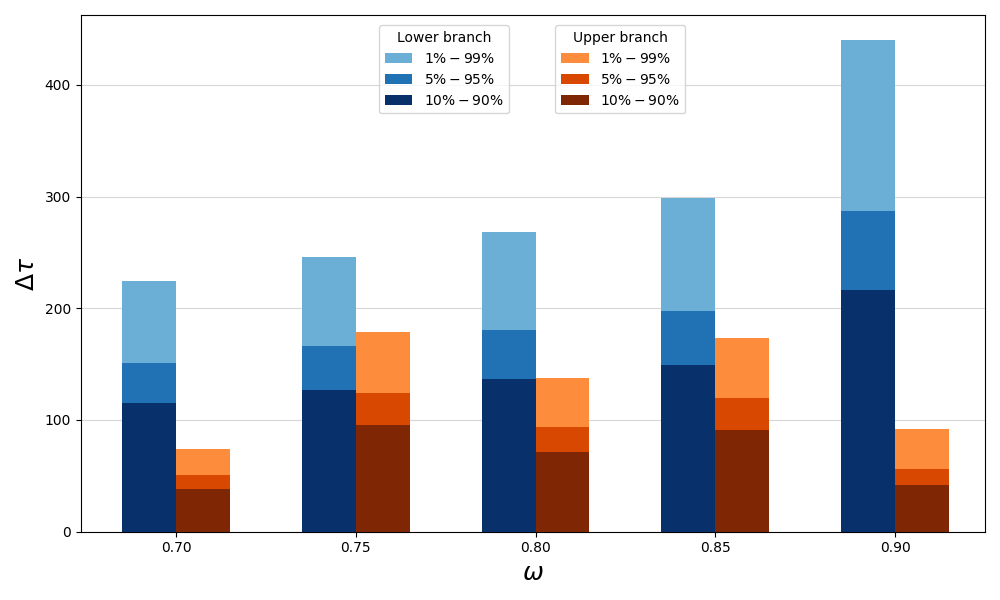

In [6]:
df_lower = pd.read_csv("data/rh=0.2_lower.csv", comment="#")
omega_lower     = df_lower["omega"]
tau_i_lower     = df_lower["tau_i_1"]
delta_tau_lower = df_lower["delta_tau_1"]

df_upper = pd.read_csv("data/rh=0.2_upper.csv", comment="#")
omega_upper     = df_upper["omega"]
tau_i_upper     = df_upper["tau_i_1"]
delta_tau_upper = df_upper["delta_tau_1"]

blue  = cm.get_cmap('Blues', 5)
blues = [blue(i) for i in range(5)]
blues.reverse()

green  = cm.get_cmap('Oranges', 5)
greens = [green(i) for i in range(5)]
greens.reverse()

fig, ax2 = plt.subplots(1, 1, sharex=True, figsize=(10,6))

bar_width = 0.0150
offset = bar_width / 2

#ax1.bar(omega_lower[0:-1] - offset, df_lower["tau_i_1"][0:-1],  bar_width, color=blues[0], zorder=9)
#ax1.bar(omega_lower[0:-1] - offset, df_lower["tau_i_5"][0:-1],  bar_width, color=blues[1], zorder=8, label="Lower")
#ax1.bar(omega_lower[0:-1] - offset, df_lower["tau_i_10"][0:-1], bar_width, color=blues[2], zorder=7)

#ax1.bar(omega_upper[0:-1] + offset, df_upper["tau_i_1"][0:-1],  bar_width, color=greens[0], zorder=9)
#ax1.bar(omega_upper[0:-1] + offset, df_upper["tau_i_5"][0:-1],  bar_width, color=greens[1], zorder=8, label="upper")
#ax1.bar(omega_upper[0:-1] + offset, df_upper["tau_i_10"][0:-1], bar_width, color=greens[2], zorder=7)

#ax1.set_xlim(right=0.949)
#ax1.grid(alpha=0.5, axis="y")
##ax1.set_xlabel(r"$\omega$", fontsize=18)
#ax1.set_ylabel(r"$\tau_i$", fontsize=18)
#ax1.legend()

ax2.bar(omega_lower[0:-1] - offset, df_lower["delta_tau_1"][0:-1],  bar_width, color=blues[2], zorder=7, label=r"$1\%-99\%$")
ax2.bar(omega_lower[0:-1] - offset, df_lower["delta_tau_5"][0:-1],  bar_width, color=blues[1], zorder=8, label=r"$5\%-95\%$")
ax2.bar(omega_lower[0:-1] - offset, df_lower["delta_tau_10"][0:-1], bar_width, color=blues[0], zorder=9, label=r"$10\%-90\%$")

ax2.bar(omega_upper[0:-1] + offset, df_upper["delta_tau_1"][0:-1],  bar_width, color=greens[2], zorder=7)
ax2.bar(omega_upper[0:-1] + offset, df_upper["delta_tau_5"][0:-1],  bar_width, color=greens[1], zorder=8)
ax2.bar(omega_upper[0:-1] + offset, df_upper["delta_tau_10"][0:-1], bar_width, color=greens[0], zorder=9)

ax2.set_xlim(right=0.925)
ax2.grid(alpha=0.5, axis="y")
ax2.set_xlabel(r"$\omega$", fontsize=18)
ax2.set_ylabel(r"$\Delta \tau$", fontsize=18)
ax2.legend(title="Lower branch")

ghost_legend_handles = [
    Patch(facecolor=greens[2], label=r"$1\%-99\%$"),
    Patch(facecolor=greens[1], label=r"$5\%-95\%$"),
    Patch(facecolor=greens[0], label=r"$10\%-90\%$")
]

# Existing legend for the plot
legend1 = ax2.legend(title="Lower branch", loc=(0.33,0.81))

# Add the ghost legend
legend2 = ax2.legend(handles=ghost_legend_handles, title="Upper branch", loc=(0.525,0.81))

# Add the first legend back to the plot (since adding a second legend removes the first one)
ax2.add_artist(legend1)

plt.tight_layout();

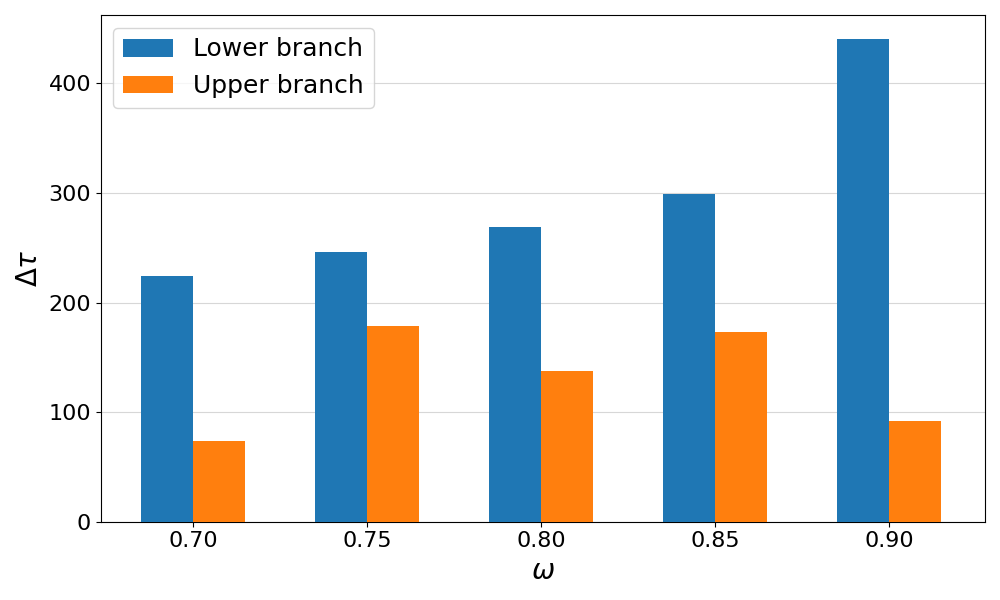

In [ ]:
df_lower = pd.read_csv("data/rh=0.2_lower.csv", comment="#")
omega_lower     = df_lower["omega"]
tau_i_lower     = df_lower["tau_i_1"]
delta_tau_lower = df_lower["delta_tau_1"]

df_upper = pd.read_csv("data/rh=0.2_upper.csv", comment="#")
omega_upper     = df_upper["omega"]
tau_i_upper     = df_upper["tau_i_1"]
delta_tau_upper = df_upper["delta_tau_1"]

fig, ax2 = plt.subplots(1, 1, sharex=True, figsize=(10,6))

bar_width = 0.0150
offset = bar_width / 2

#ax1.bar(omega_lower[0:-1] - offset, df_lower["tau_i_1"][0:-1],  bar_width, color="C0", zorder=9, label="Lower")

#ax1.bar(omega_upper[0:-1] + offset, df_upper["tau_i_1"][0:-1],  bar_width, color="C1", zorder=9, label="upper")

#ax1.set_xlim(right=0.949)
#ax1.grid(alpha=0.5, axis="y")
#ax1.set_ylabel(r"$\tau_i$", fontsize=18)
#ax1.legend()

ax2.bar(omega_lower[0:-1] - offset, df_lower["delta_tau_1"][0:-1],  bar_width, color="C0", zorder=9, label="Lower branch")
ax2.bar(omega_upper[0:-1] + offset, df_upper["delta_tau_1"][0:-1],  bar_width, color="C1", zorder=9, label="Upper branch")

ax2.set_xlim(right=0.9275)
ax2.grid(alpha=0.5, axis="y")
ax2.set_xlabel(r"$\omega$", fontsize=20)
ax2.set_ylabel(r"$\Delta \tau$", fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.legend(fontsize=18)

plt.tight_layout();

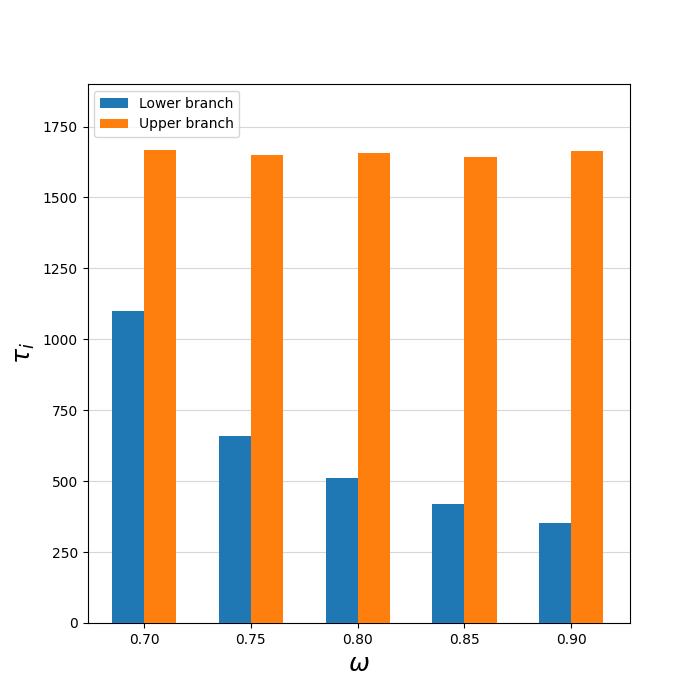

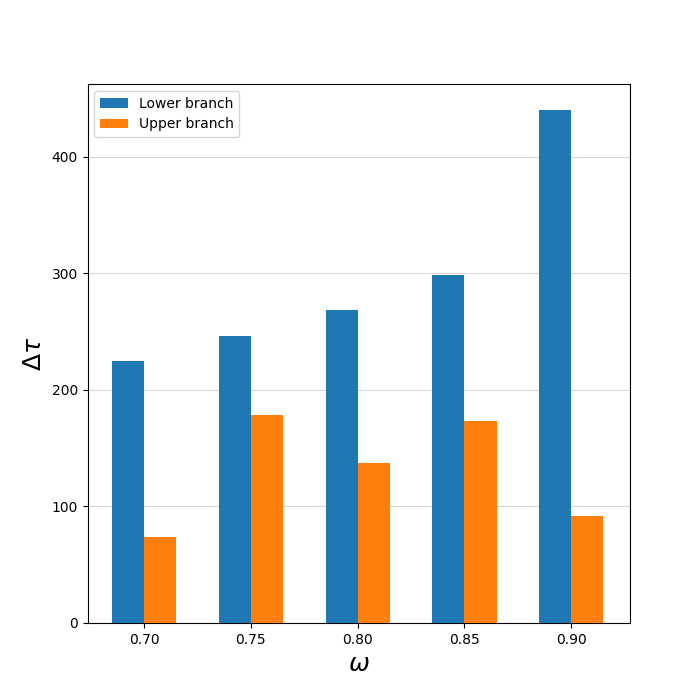

In [16]:
df_lower = pd.read_csv("data/rh=0.2_lower.csv", comment="#")
omega_lower     = df_lower["omega"]
tau_i_lower     = df_lower["tau_i_1"]
delta_tau_lower = df_lower["delta_tau_1"]

df_upper = pd.read_csv("data/rh=0.2_upper.csv", comment="#")
omega_upper     = df_lower["omega"]
tau_i_upper     = df_lower["tau_i_1"]
delta_tau_upper = df_lower["delta_tau_1"]


fig, ax1 = plt.subplots(1, 1, figsize=(7,7))

bar_width = 0.0150
offset = bar_width / 2

ax1.bar(omega_lower[0:-1] - offset, df_lower["tau_i_1"][0:-1], bar_width, color="C0", zorder=9, label="Lower branch")
ax1.bar(omega_upper[0:-1] + offset, df_upper["tau_i_1"][0:-1], bar_width, color="C1", zorder=9, label="Upper branch")

ax1.set_xlim(right=0.9275)
ax1.set_ylim(top=1900)
ax1.grid(alpha=0.5, axis="y")
ax1.set_xlabel(r"$\omega$", fontsize=18)
ax1.set_ylabel(r"$\tau_i$", fontsize=18)
ax1.legend(loc="upper left");
#fig.savefig("/home/undercover/downloads/output-1.svg", format="svg", bbox_inches='tight', pad_inches=0)


fig, ax1 = plt.subplots(1, 1, figsize=(7,7))

ax1.bar(omega_lower[0:-1] - offset, df_lower["delta_tau_1"][0:-1], bar_width, color="C0", zorder=9, label="Lower branch")
ax1.bar(omega_upper[0:-1] + offset, df_upper["delta_tau_1"][0:-1], bar_width, color="C1", zorder=9, label="Upper branch")

ax1.set_xlim(right=0.9275)
ax1.grid(alpha=0.5, axis="y")
ax1.set_xlabel(r"$\omega$", fontsize=18)
ax1.set_ylabel(r"$\Delta \tau$", fontsize=18)
ax1.legend();
#fig.savefig("/home/undercover/downloads/output-2.svg", format="svg", bbox_inches='tight', pad_inches=0)

# $\omega = 0.95$ (lower branch)

In [17]:
# csv file
csv = lambda rh: f"data/rh={float(rh)}_lower.csv"

# simulations folder
simulations = lambda rh: f"../../simulations/cloud-stat_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.950_h=4"
alpha = 0.1
omega = 0.95

# simulations go here
# in this case all of them have the fission scenario
rhs = [
    "0.1500",
    "0.2000",
    "0.2500",
    "0.3000"
]

# go over all percentages and write to the corresponding column in the file
for percentage in [1, 5, 10]:
    for i in range(0, len(rhs)):
        rh          = rhs[i]
        simulation  = simulations(rh)

        # get start stop for current percentage
        # values of (1-X)%, X% of the total initial charge of the scalar field
        sd = SimDir(simulation)
        ts = sd.timeseries
        Q_phi = ts.scalar["Q_phi"]
        Q_phi = sqrt(4*pi)/alpha*(2*Q_phi.y[0])
        start, stop = (1-percentage/100)*Q_phi, (percentage/100)*Q_phi

        # import the CSV
        # the colums will be indexed by the column names
        # the rows will be indexed by the values of omega
        # due to the way this is coded, the values of omega will disappear from the dataframe, but we can fetch them via `df.index.to_list()`
        df = pd.read_csv(csv(rh), comment="#", index_col=0)
        df.index.name = None

        # some of them might not have finished running yet
        try:
            tau_i, delta_tau = get_tau_absorption(simulation, start, stop)
            print(f"{tau_i}, {delta_tau}")

        except Exception as ex:
            print(f"error on computing tau: {ex}")
            continue

        # modify the relevant entries on the dataframe
        df.loc[omega,f"tau_i_{percentage}"]     = tau_i
        df.loc[omega,f"delta_tau_{percentage}"] = delta_tau

        # update the CSV
        df = df.reset_index()                                # reset the index to include "omega" as a column
        df.rename(columns={'index': 'omega'}, inplace=True)  # rename the index column to "omega"
        os.system(f"sed -i '/^[^#]/d' {csv(rh)}")            # remove all lines that aren't comments from the CSV
        df.to_csv(csv(rh), mode='a', index=False)            # append current dataframe to the CSV

    # here's a print to seperate different percentages
    print()

RuntimeError: Folder does not exist: ../../simulations/cloud-stat_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh=0.1500-w=0.950_h=4

/tmp/ipykernel_32850/2464579695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blue  = cm.get_cmap('Blues', 5)


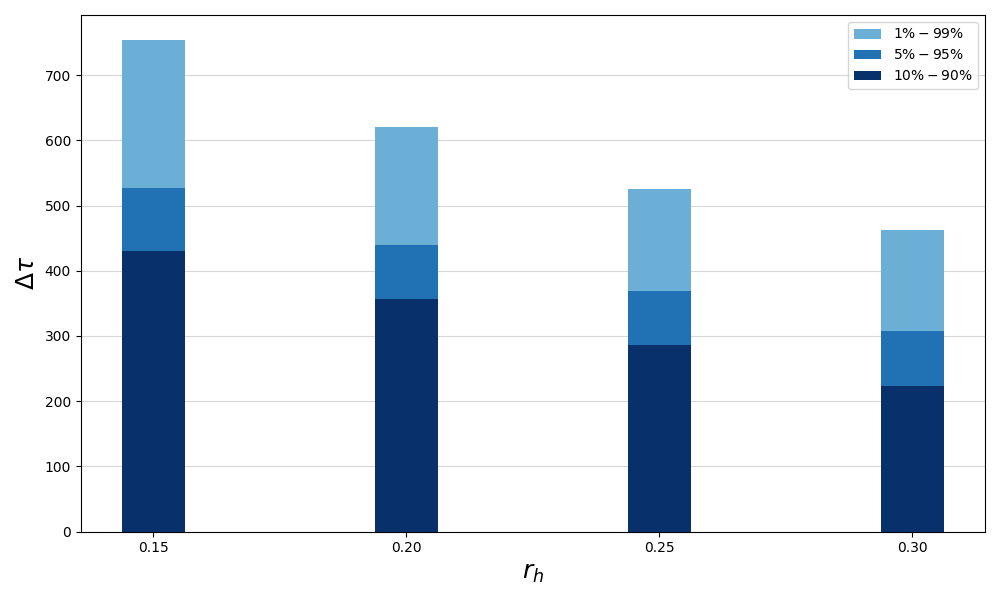

In [18]:
fig, ax2 = plt.subplots(1, 1, sharex=True, figsize=(10,6))

bar_width = 0.0125

blue  = cm.get_cmap('Blues', 5)
blues = [blue(i) for i in range(5)]
blues.reverse()

for i in range(0, len(rhs)):
    rh = float(rhs[i])
    df = pd.read_csv(csv(rh), comment="#", index_col=0)
    df.index.name = None

    #ax1.bar(rh, df.loc[0.95,"tau_i_1"],  bar_width, color=blues[2], zorder=9)
    #ax1.bar(rh, df.loc[0.95,"tau_i_5"],  bar_width, color=blues[1], zorder=8)
    #ax1.bar(rh, df.loc[0.95,"tau_i_10"], bar_width, color=blues[0], zorder=7)

    label1 = ""
    label2 = ""
    label3 = ""
    if i == len(rhs)-1:
        label1 = r"$1\%-99\%$"
        label2 = r"$5\%-95\%$"
        label3 = r"$10\%-90\%$"

    ax2.bar(rh, df.loc[0.95,"delta_tau_1"],  bar_width, color=blues[2], zorder=7, label=label1)
    ax2.bar(rh, df.loc[0.95,"delta_tau_5"],  bar_width, color=blues[1], zorder=8, label=label2)
    ax2.bar(rh, df.loc[0.95,"delta_tau_10"], bar_width, color=blues[0], zorder=9, label=label3)

#ax1.set_xticks([0.15,0.2,0.25,0.3])
#ax1.grid(alpha=0.5, axis="y")
##ax1.set_xlabel(r"$r_h$", fontsize=18)
#ax1.set_ylabel(r"$\tau_i$", fontsize=18)
##ax1.legend()

ax2.set_xticks([0.15,0.2,0.25,0.3])
ax2.grid(alpha=0.5, axis="y")
ax2.set_xlabel(r"$r_h$", fontsize=18)
ax2.set_ylabel(r"$\Delta \tau$", fontsize=18)
ax2.legend()

plt.tight_layout();

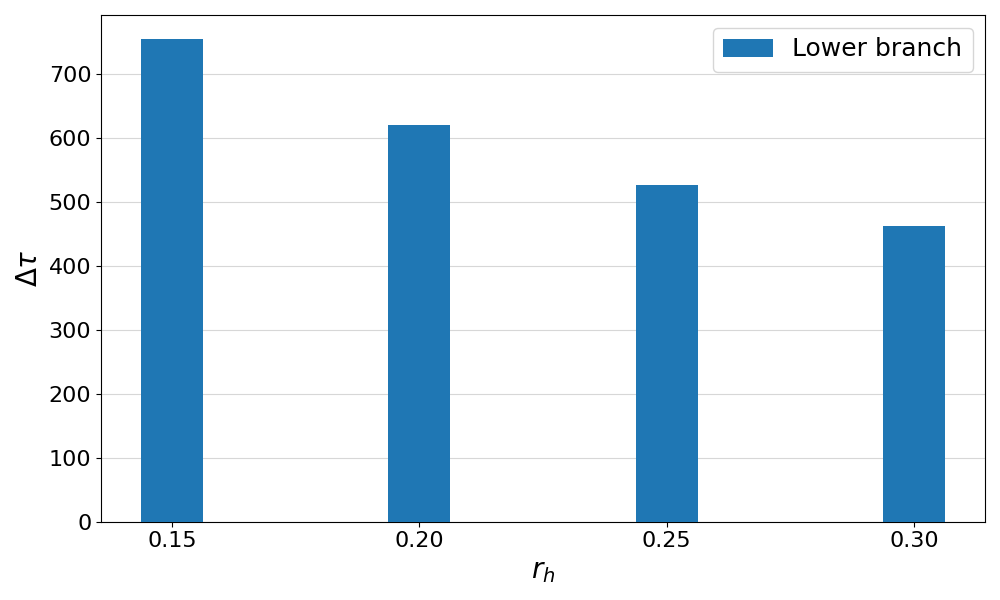

In [ ]:
fig, ax2 = plt.subplots(1, 1, sharex=True, figsize=(10,6))

bar_width = 0.0125

hacky_label = 0
for i in range(0, len(rhs)):
    rh = float(rhs[i])
    df = pd.read_csv(csv(rh), comment="#", index_col=0)
    df.index.name = None

    if hacky_label == 0:
        ax2.bar(rh, df.loc[0.95,"delta_tau_1"],  bar_width, color="C0", zorder=7, label="Lower branch")
        hacky_label = 1

    #ax1.bar(rh, df.loc[0.95,"tau_i_1"],  bar_width, color="C0", zorder=9)
    ax2.bar(rh, df.loc[0.95,"delta_tau_1"],  bar_width, color="C0", zorder=7)

#ax1.set_xticks([0.15,0.2,0.25,0.3])
#ax1.grid(alpha=0.5, axis="y")
##ax1.set_xlabel(r"$r_h$", fontsize=18)
#ax1.set_ylabel(r"$\tau_i$", fontsize=18)

ax2.set_xticks([0.15,0.2,0.25,0.3])
ax2.grid(alpha=0.5, axis="y")
ax2.set_xlabel(r"$r_h$", fontsize=20)
ax2.set_ylabel(r"$\Delta \tau$", fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.legend(fontsize=18)

plt.tight_layout();

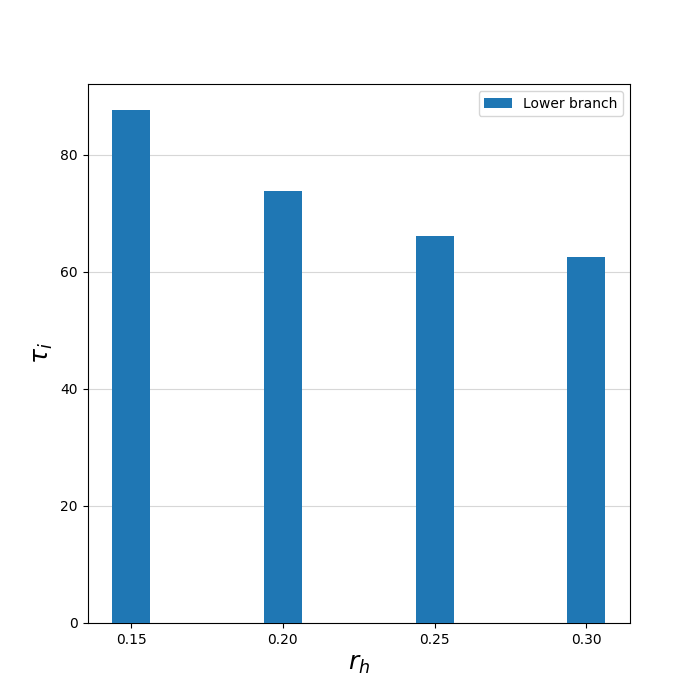

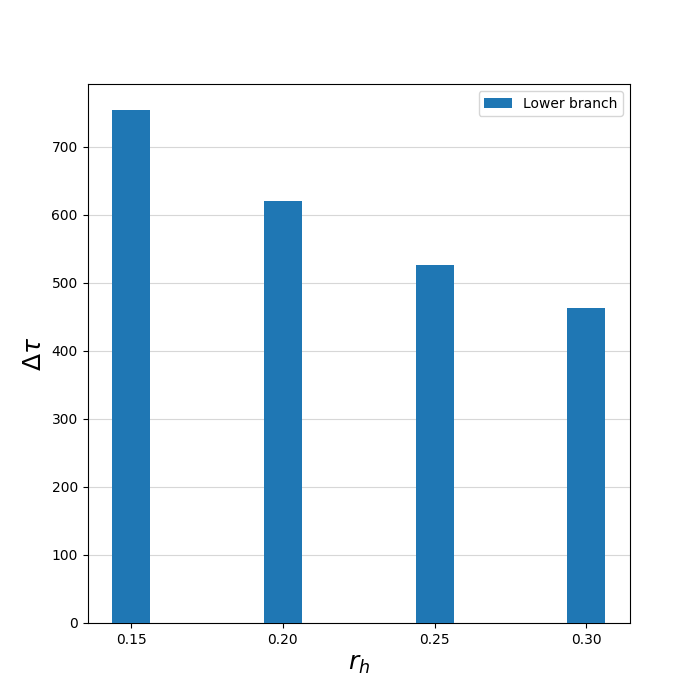

In [12]:
bar_width = 0.0125

fig, ax1 = plt.subplots(1, 1, sharex=True, figsize=(7,7))

hacky_label = 0
for i in range(0, len(rhs)):
    rh = float(rhs[i])
    df = pd.read_csv(csv(rh), comment="#", index_col=0)
    df.index.name = None

    if hacky_label == 0:
        ax1.bar(rh, df.loc[0.95,"tau_i_1"], bar_width, color="C0", zorder=9, label="Lower branch")
        hacky_label = 1
    else:
        ax1.bar(rh, df.loc[0.95,"tau_i_1"], bar_width, color="C0", zorder=9)

ax1.set_xticks([0.15,0.2,0.25,0.3])
ax1.grid(alpha=0.5, axis="y")
ax1.set_xlabel(r"$r_h$", fontsize=18)
ax1.set_ylabel(r"$\tau_i$", fontsize=18)
ax1.legend()
#fig.savefig("/home/undercover/downloads/output-1.svg", format="svg", bbox_inches='tight', pad_inches=0)

fig, ax2 = plt.subplots(1, 1, sharex=True, figsize=(7,7))

hacky_label = 0
for i in range(0, len(rhs)):
    rh = float(rhs[i])
    df = pd.read_csv(csv(rh), comment="#", index_col=0)
    df.index.name = None

    if hacky_label == 0:
        ax2.bar(rh, df.loc[0.95,"delta_tau_1"], bar_width, color="C0", zorder=7, label="Lower branch")
        hacky_label = 1
    else:
        ax2.bar(rh, df.loc[0.95,"delta_tau_1"], bar_width, color="C0", zorder=7)

ax2.set_xticks([0.15,0.2,0.25,0.3])
ax2.grid(alpha=0.5, axis="y")
ax2.set_xlabel(r"$r_h$", fontsize=18)
ax2.set_ylabel(r"$\Delta \tau$", fontsize=18)
ax2.legend();
#fig.savefig("/home/undercover/downloads/output-2.svg", format="svg", bbox_inches='tight', pad_inches=0)